In [3]:
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import callbacks
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D
from tensorflow.keras.metrics import Precision, Recall

2024-03-15 17:26:52.780168: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-15 17:26:52.780287: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-15 17:26:52.917055: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
train_dir = "/kaggle/input/brain-tumor-mri-dataset/Training"
test_dir = "/kaggle/input/brain-tumor-mri-dataset/Testing"

resize_size = (240,240)

batch_size = 32

In [12]:
test_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory = test_dir ,
    image_size = resize_size ,
    label_mode = "categorical" ,
    batch_size = batch_size ,
    )

# Define classes names
class_names = test_data.class_names
print("Class names:", class_names)

Found 1311 files belonging to 4 classes.
Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [11]:
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory=train_dir,
    image_size=resize_size,
    label_mode="categorical",
    batch_size=batch_size,
    validation_split=0.2,  # 20% for validation
    subset="training",
    seed=123
)


#validation dataset
val_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory=train_dir,
    image_size=resize_size,
    label_mode="categorical",
    batch_size=batch_size,
    validation_split=0.2,  # 20% for validation
    subset="validation",
    seed=123
)

Found 5712 files belonging to 4 classes.
Using 4570 files for training.
Found 5712 files belonging to 4 classes.
Using 1142 files for validation.


In [13]:
def showSampleImages(data):
    class_names=data.class_names
    plt.figure(figsize=(12, 12))
    for images,labels in data.take(1):
        for i in range(9):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[tf.argmax(labels[i])])
            plt.axis("off")

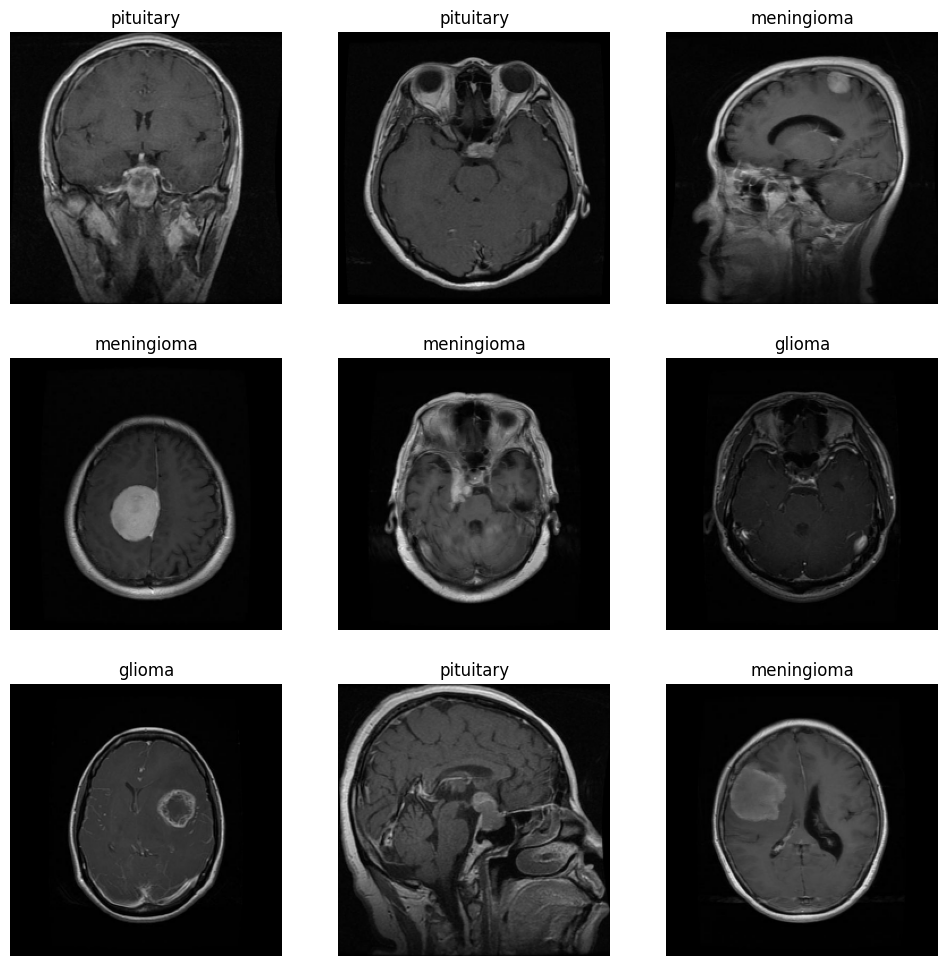

In [14]:
showSampleImages(train_data)

# Ckecking Count of data

In [15]:
def print_count_and_bar_graph(data,data_name,pallete_style="deep"):
    class_names=data.class_names
    ds=pd.DataFrame({'Class':class_names,'Count':len(class_names)*[0]})
    
    #Looping over the data
    for images,labels in data:
        for i in range(len(images)):
            for category in class_names:
                if class_names[tf.argmax(labels[i])]==category:
                    ds.loc[ds['Class']==category,'Count']+=1
    #print count
    for category in class_names:
        print(f"{category} : {ds.loc[ds['Class']==category,'Count']}")

    #print bar plot
    plt.figure(figsize=(12,7))
    ax = sns.barplot(data=ds , x='Class',y='Count', palette=pallete_style)
    sns.set(style="dark",palette="colorblind")
    plt.title('Count of images in each class of '+data_name, fontsize=20)
    ax.bar_label(ax.containers[0])
    plt.show()


glioma : 0    1090
Name: Count, dtype: int64
meningioma : 1    1042
Name: Count, dtype: int64
notumor : 2    1274
Name: Count, dtype: int64
pituitary : 3    1164
Name: Count, dtype: int64


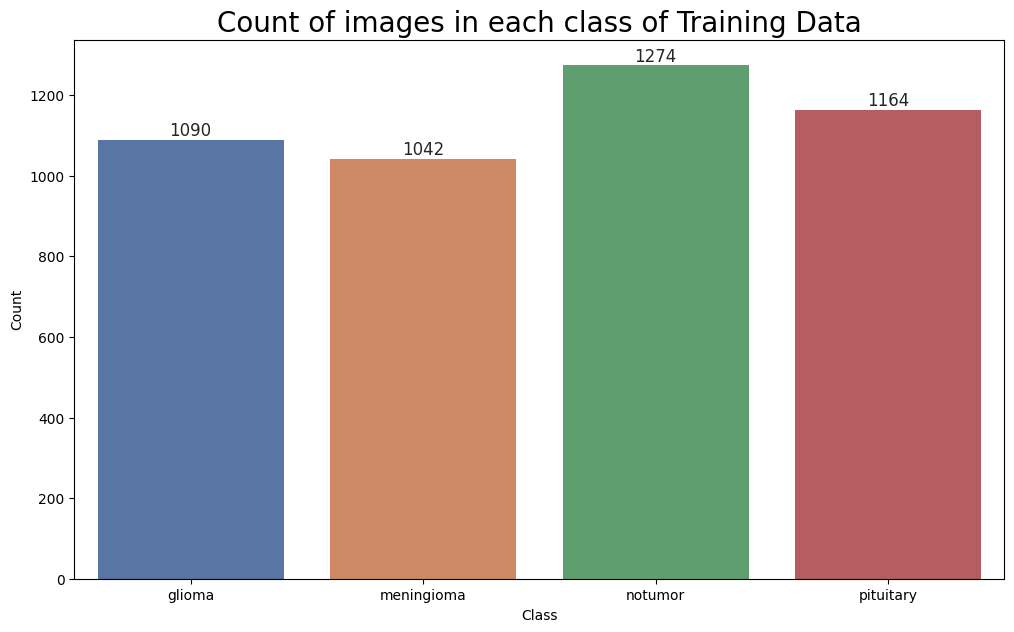

In [16]:
print_count_and_bar_graph(train_data,"Training Data")

glioma : 0    1090
Name: Count, dtype: int64
meningioma : 1    1042
Name: Count, dtype: int64
notumor : 2    1274
Name: Count, dtype: int64
pituitary : 3    1164
Name: Count, dtype: int64


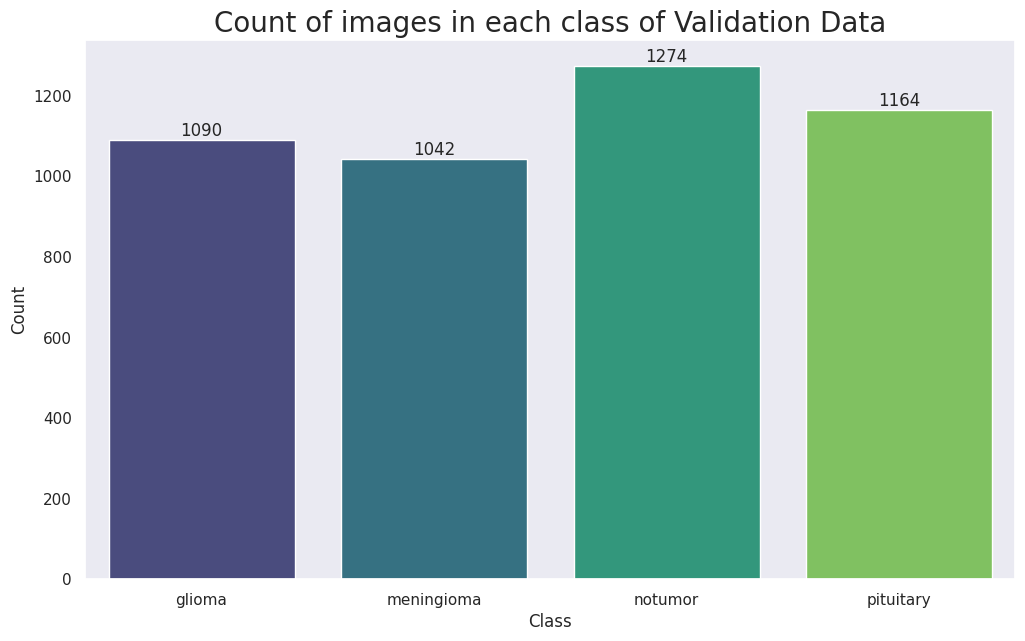

In [17]:
print_count_and_bar_graph(train_data,"Validation Data",pallete_style="viridis")

glioma : 0    300
Name: Count, dtype: int64
meningioma : 1    306
Name: Count, dtype: int64
notumor : 2    405
Name: Count, dtype: int64
pituitary : 3    300
Name: Count, dtype: int64


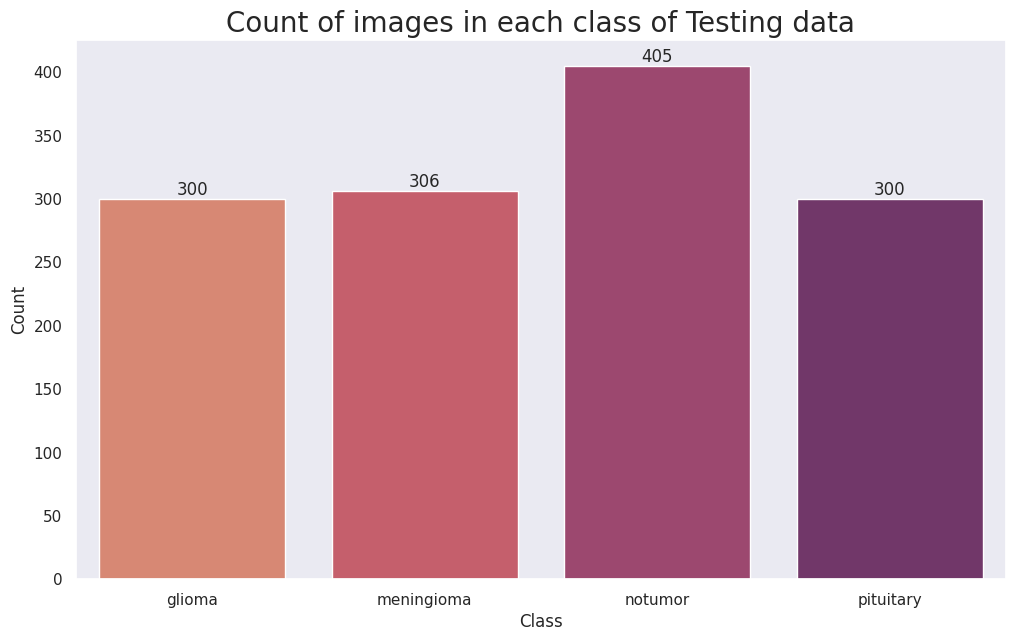

In [18]:
print_count_and_bar_graph(test_data,"Testing data",pallete_style="flare")

In [19]:
from tensorflow.keras.models import Model
from tensorflow.keras.applications import vgg16
from tensorflow.keras.optimizers import  SGD

In [56]:
img_size=(240,240,3)

vgg = vgg16.VGG16(weights='imagenet', include_top=False, input_shape = img_size)

  

In [57]:
vgg.summary()


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 240, 240, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 240, 240, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 120, 120, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 120, 120, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 60, 60, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 60, 60, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 60, 60, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 30, 30, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 30, 30, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 30, 30, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 15, 15, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [58]:
for layer in vgg.layers[:-5]:    #Set block5 trainable, all others as non-trainable
    print(layer.name)
    layer.trainable = False #All others as non-trainable

input_layer_3
block1_conv1
block1_conv2
block1_pool
block2_conv1
block2_conv2
block2_pool
block3_conv1
block3_conv2
block3_conv3
block3_pool
block4_conv1
block4_conv2
block4_conv3


In [59]:
def get_model(input_shape = img_size):
    x = vgg.output
    x = GlobalAveragePooling2D()(x) #Using GlobalAveragePooling in place of flatten. 
    x = Dense(4, activation="softmax")(x)  #defining this as multiclass problem. 

    model = Model(vgg.input, x)
    model.compile(loss = "categorical_crossentropy", 
                  optimizer = SGD(learning_rate=0.0001, momentum=0.9),
                  metrics=['accuracy', Precision(), Recall()])
    
    return model

In [60]:
model=get_model(input_shape=img_size)

model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 240, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 240, 240, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 240, 240, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 120, 120, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 120, 120, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 120, 120, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 60, 60, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 60, 60, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 60, 60, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 60, 60, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 30, 30, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 30, 30, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 30, 30, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 15, 15, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 15, 15, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,716,740 (56.14 MB)

 Trainable params: 7,081,476 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
tf.keras.utils.plot_model(model, show_shapes=True)

In [62]:
callback_list=[
    callbacks.EarlyStopping(monitor="val_accuracy",patience=5,restore_best_weights=True),
    callbacks.EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True),
    callbacks.ReduceLROnPlateau(factor=0.8,monitor="val_accuracy",patience=3)
]

In [63]:
Model_History = model.fit(train_data 
                              ,validation_data = val_data ,
                              epochs = 30  ,
                              verbose = 1 ,
                              callbacks = callback_list)

Epoch 1/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 20s 121ms/step - accuracy: 0.3570 - loss: 4.9323 - precision_4: 0.4844 - recall_4: 0.1388 - val_accuracy: 0.5753 - val_loss: 421.9611 - val_precision_4: 0.7848 - val_recall_4: 0.2618 - learning_rate: 1.0000e-04
Epoch 2/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.5729 - loss: 0.9686 - precision_4: 0.7368 - recall_4: 0.3077 - val_accuracy: 0.6646 - val_loss: 390.4250 - val_precision_4: 0.7312 - val_recall_4: 0.5359 - learning_rate: 1.0000e-04
Epoch 3/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.6385 - loss: 0.7586 - precision_4: 0.7628 - recall_4: 0.5009 - val_accuracy: 0.7180 - val_loss: 579.7239 - val_precision_4: 0.7629 - val_recall_4: 0.6594 - learning_rate: 1.0000e-04
Epoch 4/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 15s 105ms/step - accuracy: 0.6768 - loss: 0.6932 - precision_4: 0.7485 - recall_4: 0.5921 - val_accuracy: 0.7609 - val_loss: 466.3731 - val_precision_4: 0.8098 - val_recall_4: 0.6637 - learning_rate: 1.0000e

In [66]:
def plot_metrices_graphs(Model_History, start=0):
    metrices = {
        "train_Loss": Model_History.history['loss'],
        "val_Loss": Model_History.history['val_loss'],
        "train_Accuracy": Model_History.history['accuracy'],
        "val_Accuracy": Model_History.history['val_accuracy'],
        "train_Precision": Model_History.history['precision_4'],
        "val_Precision": Model_History.history['val_precision_4'],
        "train_Recall": Model_History.history['recall_4'],
        "val_Recall": Model_History.history['val_recall_4']
    }

    bestEpoch = {
        "Loss": np.argmin(metrices["val_Loss"]),
        "Accuracy": np.argmax(metrices["val_Accuracy"]),
        "Precision": np.argmax(metrices["val_Precision"]),
        "Recall": np.argmax(metrices["val_Recall"])
    }

    Epochs = [i + 1 for i in range(start, len(metrices['train_Accuracy']))]

    plt.figure(figsize=(20, 12))
    plt.style.use('fivethirtyeight')

    i = 0
    for j in range(0, 4):
        plt.subplot(2, 2, j+1)
        plt.plot(Epochs, metrices["train_" + list(bestEpoch.keys())[j]], 'r', label=f'Training {list(bestEpoch.keys())[j]}')
        plt.plot(Epochs, metrices["val_" + list(bestEpoch.keys())[j]], 'g', label=f'Validation {list(bestEpoch.keys())[j]}')
        plt.scatter(bestEpoch[list(bestEpoch.keys())[j]], metrices["val_" + list(bestEpoch.keys())[j]][bestEpoch[list(bestEpoch.keys())[j]]], s=150, c='blue', label=f'Best Epoch = {bestEpoch[list(bestEpoch.keys())[j]]}')
        plt.title(f'Training and Validation {list(bestEpoch.keys())[j]}')
        plt.xlabel('Epochs')
        plt.ylabel(f'{list(bestEpoch.keys())[j]}')
        plt.legend()
        plt.grid(True)
        i += 1

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    plt.show()


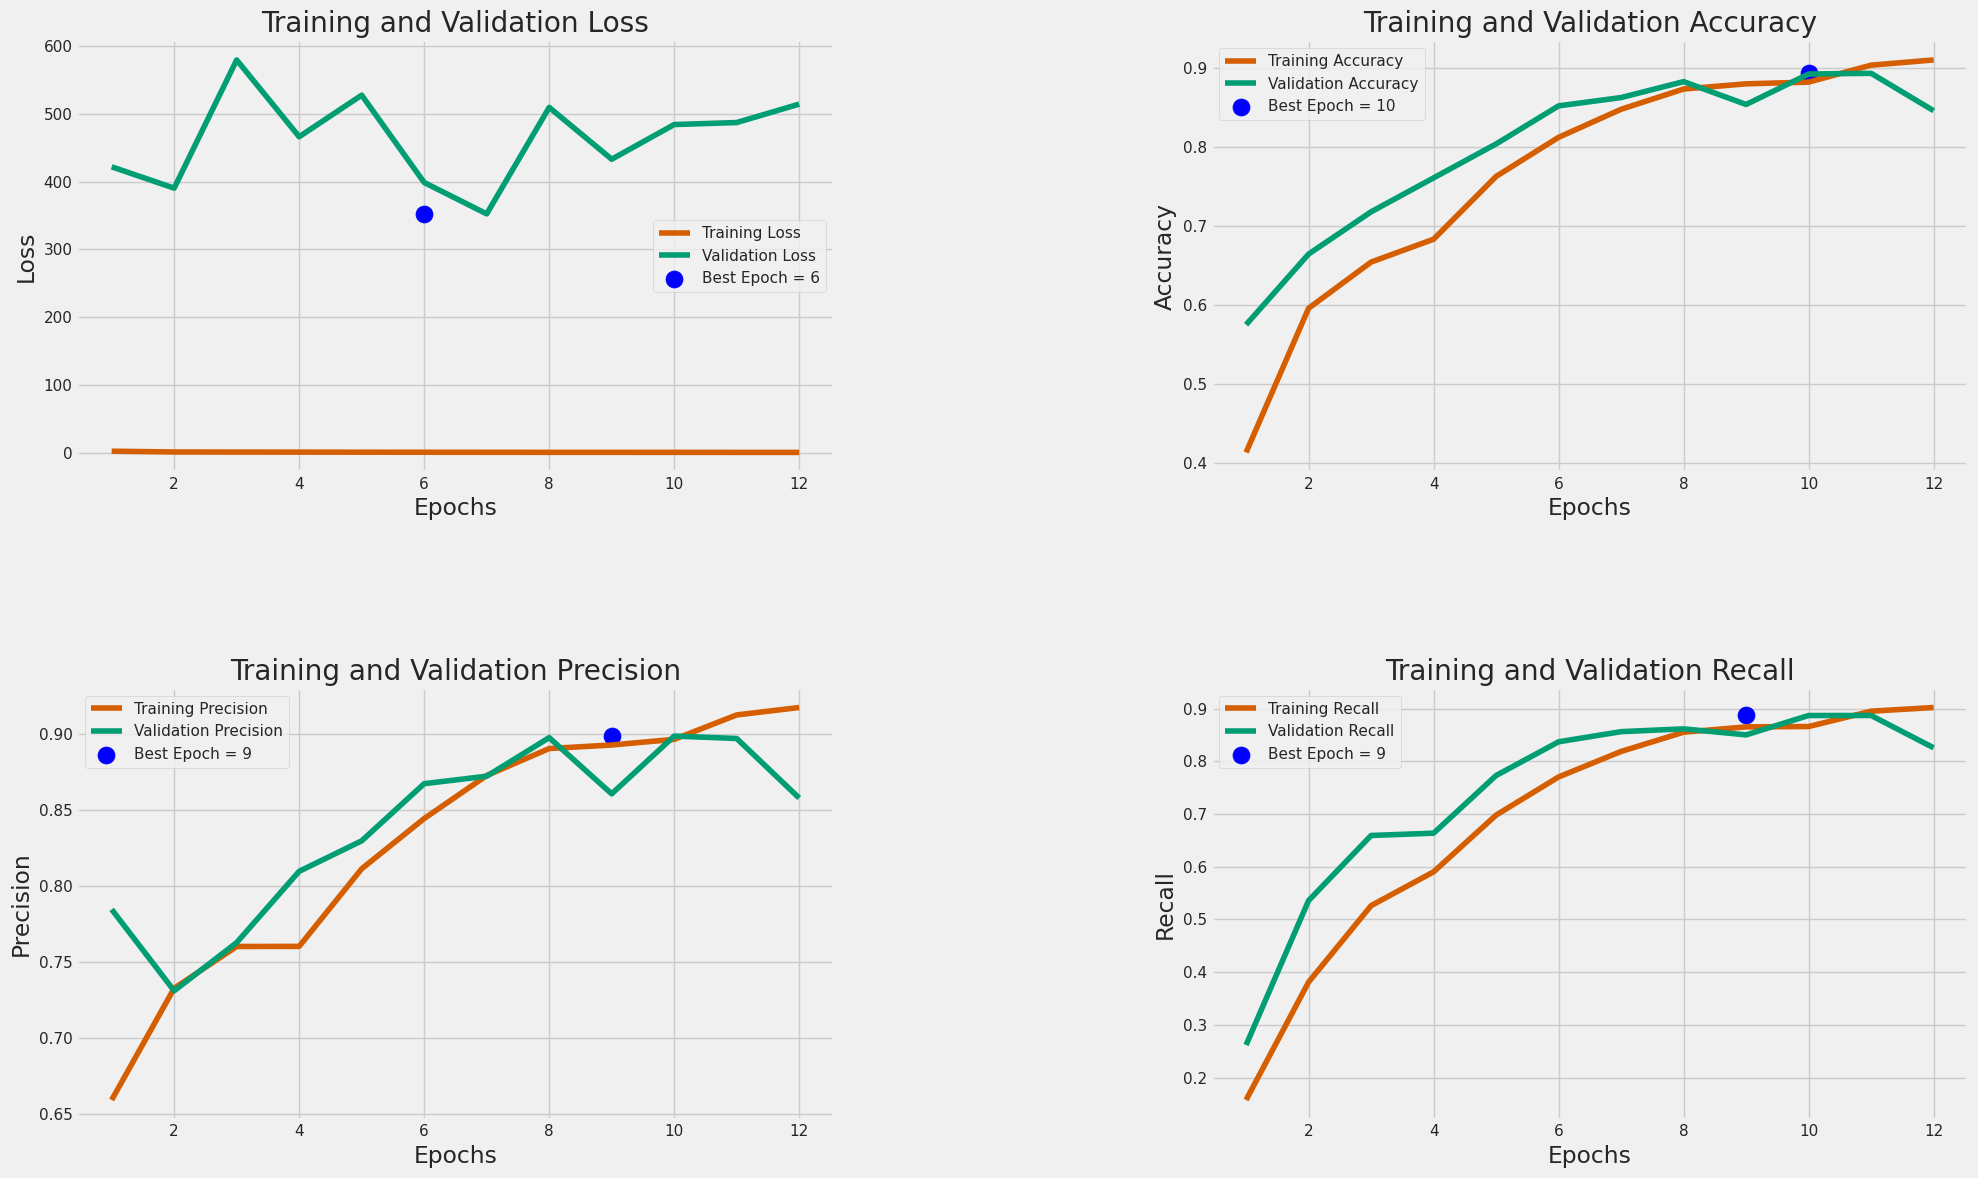

In [67]:
plot_metrices_graphs(Model_History)

In [68]:
def Evaluate_Model(model,train_data,test_data):
    train_score = model.evaluate(train_data, verbose=1)
    test_score = model.evaluate(test_data,verbose=1)

    print(f"Train Loss: {train_score[0]:.4f}")
    print(f"Train Accuracy: {train_score[1]*100:.2f}%")
    print('-' * 30)
    print(f"Test Loss: {test_score[0]:.4f}")
    print(f"Test Accuracy: {test_score[1]*100:.2f}%")

In [69]:
Evaluate_Model(model,train_data,test_data)

143/143 ━━━━━━━━━━━━━━━━━━━━ 12s 80ms/step - accuracy: 0.8773 - loss: 0.3271 - precision_4: 0.8837 - recall_4: 0.8689
40/41 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8280 - loss: 0.4682 - precision_4: 0.8367 - recall_4: 0.8197

2024-03-15 18:13:00.822167: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 57600: 3.94968, expected 3.38645
2024-03-15 18:13:00.822221: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 57613: 4.02395, expected 3.46073
2024-03-15 18:13:00.822231: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 57627: 4.41065, expected 3.84742
2024-03-15 18:13:00.822239: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 57648: 3.74156, expected 3.17833
2024-03-15 18:13:00.822246: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 57649: 4.29365, expected 3.73042
2024-03-15 18:13:00.822254: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 57653: 3.27829, expected 2.71506
2024-03-15 18:13:00.822261: E external/local_xla/xla/service/gpu/buffer_comparator.cc:1137] Difference at 57654: 2.98417, expected 2.42094
2024-03-15 18:13:00.822269:

41/41 ━━━━━━━━━━━━━━━━━━━━ 19s 465ms/step - accuracy: 0.8277 - loss: 0.4681 - precision_4: 0.8364 - recall_4: 0.8193
Train Loss: 0.3373
Train Accuracy: 87.59%
------------------------------
Test Loss: 0.4661
Test Accuracy: 82.15%


In [70]:
from sklearn.metrics import classification_report, confusion_matrix

def printClassificationReportAndConfusionMaxtrix(model, class_names, data):
    true_labels = []
    predicted_labels = []

    for images, labels in data:
        true_labels.extend(np.argmax(labels.numpy(),axis=1))  # Convert one-hot encoded labels to class indices
        predicted_labels.extend(np.argmax(model.predict(images),axis=1))  # Obtain model predictions

    # Print classification report
    print("\n" * 5)
    print(classification_report(true_labels, predicted_labels, target_names=class_names))
    print("\n" * 5)

    # Compute the confusion matrix
    conf_matrix = confusion_matrix(true_labels, predicted_labels)

    # Plot the confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 653ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━

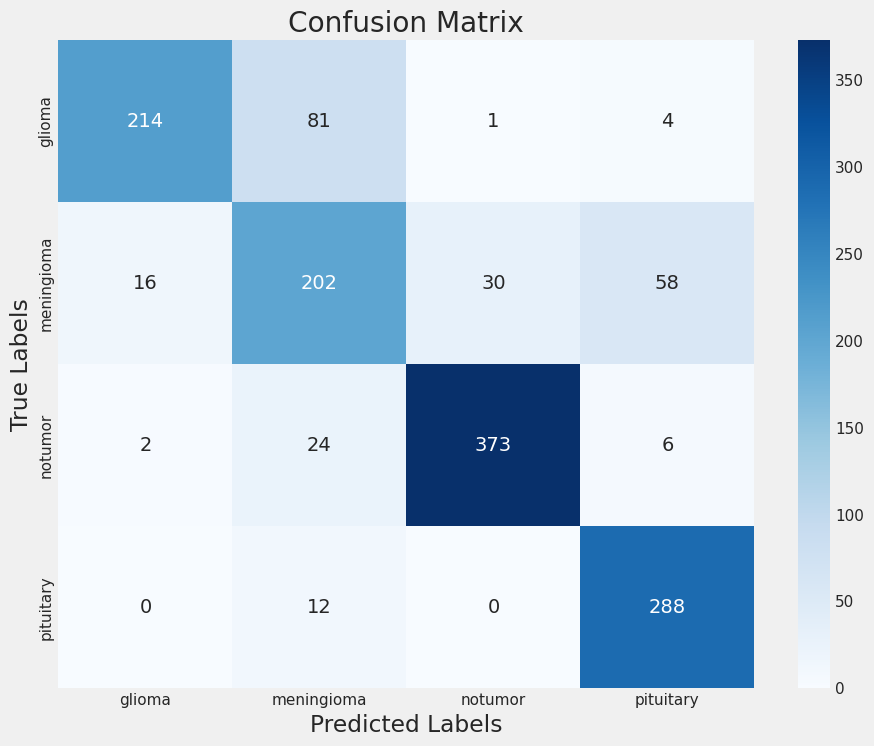

In [71]:
printClassificationReportAndConfusionMaxtrix(model,class_names,test_data)

In [72]:
model.save("tumor.h5")

In [ ]:
import cv2
from PIL import Image
import scipy  #Used to upsample our image
from matplotlib.patches import Rectangle #To add a rectangle overlay to the image
from skimage.feature.peak import peak_local_max  #To detect hotspots in 2D images. 

In [ ]:
def getImage(img_path):
    image = cv2.imread(img_path)
    image = Image.fromarray(image, 'RGB')
    image = image.resize(resize_size)
    image = np.array(image)
    return image

In [ ]:
def plot_heatmap(img):
  
    pred = model.predict(np.expand_dims(img, axis=0))
    pred_class = np.argmax(pred)
    #Get weights for all classes from the prediction layer
    last_layer_weights = model.layers[-1].get_weights()[0] #Prediction layer
    #Get weights for the predicted class.
    last_layer_weights_for_pred = last_layer_weights[:, pred_class]
    #Get output from the last conv. layer
    last_conv_model = Model(model.input, model.get_layer("block5_conv3").output)
    last_conv_output = last_conv_model.predict(img[np.newaxis,:,:,:])
    last_conv_output = np.squeeze(last_conv_output)
    
    #Upsample/resize the last conv. output to same size as original image
    h = int(img.shape[0]/last_conv_output.shape[0])
    w = int(img.shape[1]/last_conv_output.shape[1])
    upsampled_last_conv_output = scipy.ndimage.zoom(last_conv_output, (h, w, 1), order=1)
    
    heat_map = np.dot(upsampled_last_conv_output.reshape((img.shape[0]*img.shape[1], 512)), 
                 last_layer_weights_for_pred).reshape(img.shape[0],img.shape[1])
    
    #Since we have a lot of dark pixels where the edges may be thought of as 
    #high anomaly, let us drop all heat map values in this region to 0.
    #This is an optional step based on the image. 
    heat_map[img[:,:,0] == 0] = 0  #All dark pixels outside the object set to 0
    
    #Detect peaks (hot spots) in the heat map. We will set it to detect maximum 5 peaks.
    #with rel threshold of 0.5 (compared to the max peak). 
    peak_coords = peak_local_max(heat_map, num_peaks=5, threshold_rel=0.5, min_distance=10) 

    plt.imshow(img.astype('float32').reshape(img.shape[0],img.shape[1],3))
    plt.imshow(heat_map, cmap='jet', alpha=0.30)
    plt.title(class_names[pred_class])
    for i in range(0,peak_coords.shape[0]):
        y = peak_coords[i,0]
        x = peak_coords[i,1]
        plt.gca().add_patch(Rectangle((x-25, y-25), 50,50,linewidth=1,edgecolor='r',facecolor='none'))


In [ ]:
def showPredictionStatistics(img_path,class_names=class_names,size=resize_size):
    plt.figure(figsize=(6, 6))
    img=getImage(img_path)
    predictions = model.predict(np.expand_dims(img, axis=0))
    probs = list(predictions[0]*100)
    print(probs)
    labels = class_names
    plt.subplot(2, 1, 1)
    plt.imshow(img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Percentage', fontsize=20)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')
    plt.show()